# Efficient Portfolio Frontier in Python

https://www.youtube.com/watch?v=ymM0xJUgGLo

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt #!pip install yfinance

In [2]:
# importing data
tickers    = ['BA', 'C', 'CVX', 'ORCL', 'PEP', 'PFE', 'TSLA']
start      = '2015-12-31'
end        = '2023-10-31'
prices_df  = yf.download(' '.join(tickers), start, end)['Adj Close']
returns_df = prices_df.pct_change()[1:]

Failed to get ticker 'ORCL' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'C' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'CVX' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'PFE' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'PEP' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'TSLA' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'BA' reason: Expecting value: line 1 column 1 (char 0)


[*********************100%%**********************]  6 of 7 completed


7 Failed downloads:



[**********************86%%***************       ]  6 of 7 completed

['ORCL', 'C', 'CVX', 'PFE', 'TSLA', 'PEP', 'BA']: Exception('%ticker%: No timezone found, symbol may be delisted')


In [10]:
returns_df

,BA,C,CVX,ORCL,PEP,PFE,TSLA
Date,,,,,,,
2016-01-04,-0.028287,-0.011981,-0.012339,-0.017317,-0.011509,-0.010223,-0.069164
2016-01-05,0.004057,-0.005281,0.008554,-0.003077,0.006885,0.007199,0.000090
2016-01-06,-0.015878,-0.014550,-0.039505,0.005051,0.000302,-0.017713,-0.019648
2016-01-07,-0.041922,-0.051077,-0.035436,-0.021775,-0.019200,-0.006643,-0.015477
2016-01-08,-0.022705,-0.030067,-0.010720,-0.011130,-0.003690,-0.012739,-0.021563
...,...,...,...,...,...,...,...
2023-10-24,0.007347,0.001029,-0.025081,-0.004438,0.013181,-0.013294,0.020936
2023-10-25,-0.025389,-0.008220,-0.004979,-0.017151,0.000987,0.009859,-0.018936
2023-10-26,0.007652,0.018907,-0.007185,-0.010155,-0.005790,0.013993,-0.031353


In [16]:
# calculating the annualised return vector, r, and the annualised covariance matrix, cov
r   = ((1 + returns_df).prod())**(252/len(returns_df)) - 1 # 252 trading days in the year
cov = returns_df.cov()*252
e   = np.ones(len(tickers))

In [17]:
cov

,BA,C,CVX,ORCL,PEP,PFE,TSLA
BA,0.184752,0.089858,0.069413,0.041165,0.026825,0.026591,0.076090
C,0.089858,0.119509,0.067477,0.041576,0.023716,0.027408,0.057830
CVX,0.069413,0.067477,0.096727,0.029324,0.020607,0.022045,0.039453
ORCL,0.041165,0.041576,0.029324,0.074453,0.023586,0.022686,0.038289
PEP,0.026825,0.023716,0.020607,0.023586,0.037520,0.018886,0.021353
PFE,0.026591,0.027408,0.022045,0.022686,0.018886,0.054903,0.015386
TSLA,0.076090,0.057830,0.039453,0.038289,0.021353,0.015386,0.342981


In [18]:
r

BA      0.044574
C      -0.008884
CVX     0.109849
ORCL    0.158856
PEP     0.094805
PFE     0.037280
TSLA    0.379034
dtype: float64

In [19]:
# defining the investable universe
icov = np.linalg.inv(cov) # inverse covariance matrix
h    = np.matmul(e, icov) # h-vector, risk facet
g    = np.matmul(r, icov) # g-vector, returns facet
a    = np.sum(e*h)
b    = np.sum(r*h)
c    = np.sum(r*g)
d    = a*c - b**2

In [23]:
icov

array([[ 9.35207206e+00, -4.60509633e+00, -2.62908466e+00,
        -6.45319634e-01, -1.34628874e+00, -2.12476589e-01,
        -8.30480102e-01],
       [-4.60509633e+00,  1.81484669e+01, -7.44837085e+00,
        -3.54937312e+00, -4.57154513e-01, -2.02810056e+00,
        -6.65910102e-01],
       [-2.62908466e+00, -7.44837085e+00,  1.84040245e+01,
        -4.02221830e-01, -2.58666117e+00, -1.33885113e+00,
        -1.18775935e-02],
       [-6.45319634e-01, -3.54937312e+00, -4.02221830e-01,
         1.96284561e+01, -7.39811058e+00, -3.09455369e+00,
        -8.03937694e-01],
       [-1.34628874e+00, -4.57154513e-01, -2.58666117e+00,
        -7.39811058e+00,  3.83338149e+01, -8.06355305e+00,
        -5.25599737e-01],
       [-2.12476589e-01, -2.02810056e+00, -1.33885113e+00,
        -3.09455369e+00, -8.06355305e+00,  2.38293350e+01,
         3.21601037e-01],
       [-8.30480102e-01, -6.65910102e-01, -1.18775935e-02,
        -8.03937694e-01, -5.25599737e-01,  3.21601037e-01,
         3.3215423

In [27]:
# minimum variance and tangency portfolio
mvp             = h / a
mvp_return      = b / a
mvp_risk        = (1 / a)**(1/2)

tangency        = g / b
tangency_return = c / b
tangency_risk   = c**(1/2)/b

In [28]:
mvp

array([-0.02666698, -0.01761573,  0.11598465,  0.1086532 ,  0.52237134,
        0.27384543,  0.02342811])

In [29]:
tangency

array([-0.11444309, -0.6319813 ,  0.47911039,  0.58289515,  0.48268176,
       -0.11457505,  0.31631214])

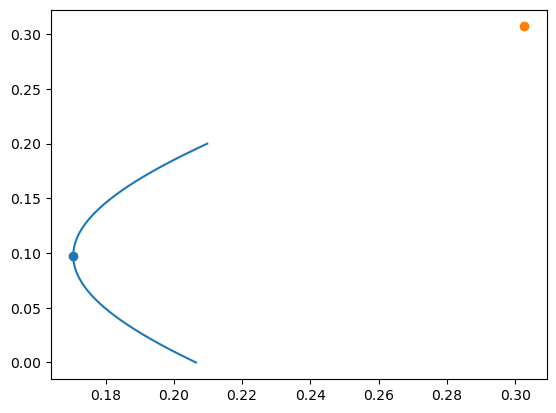

In [34]:
# plotting the efficient portfolio frontier
exp_returns = np.arange(0, 0.201, 0.001) # step of 10bps
risk        = ((a*exp_returns**2 - 2*b*exp_returns + c) / d)**(1/2)
plt.plot(risk, exp_returns)
plt.scatter(mvp_risk, mvp_return)
plt.scatter(tangency_risk, tangency_return)
plt.show()

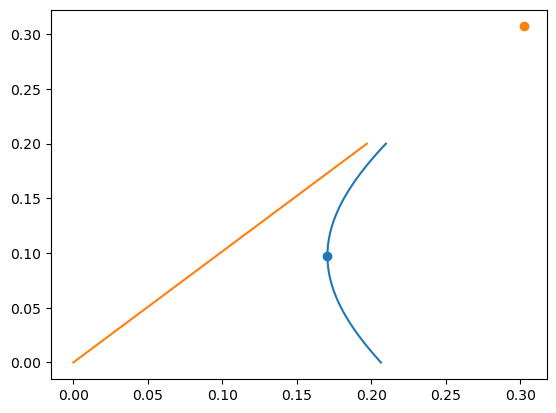

In [37]:
# plotting the securities market line
SML_slope = 1/c**(1/2)
SML_risk = exp_returns * SML_slope

plt.plot(risk, exp_returns)
plt.plot(SML_risk, exp_returns)
plt.scatter(mvp_risk, mvp_return)
plt.scatter(tangency_risk, tangency_return)
plt.show()

In [44]:
# solving the target return problem
target_return = 0.12 # somehwere between minimum return and tangent return
if target_return < mvp_return:
    optimal_portfolio = mvp
    optimal_return = mvp_return
    optimal_risk = mvp_risk
else:
    l = (c - b * target_return) / d # l is the risk optimising element
    m = (a * target_return - b) / d # m is the return optimising element
    optimal_portfolio = 1 * h + m * g
    optimal_return = np.sum(optimal_portfolio * r)
    optimal_risk = ((a * optimal_return**2 - 2*b*optimal_return + c) / d)**(1 / 2)

print(optimal_portfolio, optimal_return, optimal_risk)

[-0.92891828 -0.67315433  4.03821732  3.79730355 18.00808925  9.40114262
  0.83918045] 3.3872012109749905 3.9275152975100376
